In [2]:
import jax.numpy as jnp
import numpy as onp
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
import pandas as pd
import seaborn as sns
import time

font = {"size": 20}
matplotlib.rc("font", **font)
matplotlib.rcParams["text.usetex"] = True

import sys
sys.path.append("../../models")
from linear_sscr import LinearCR

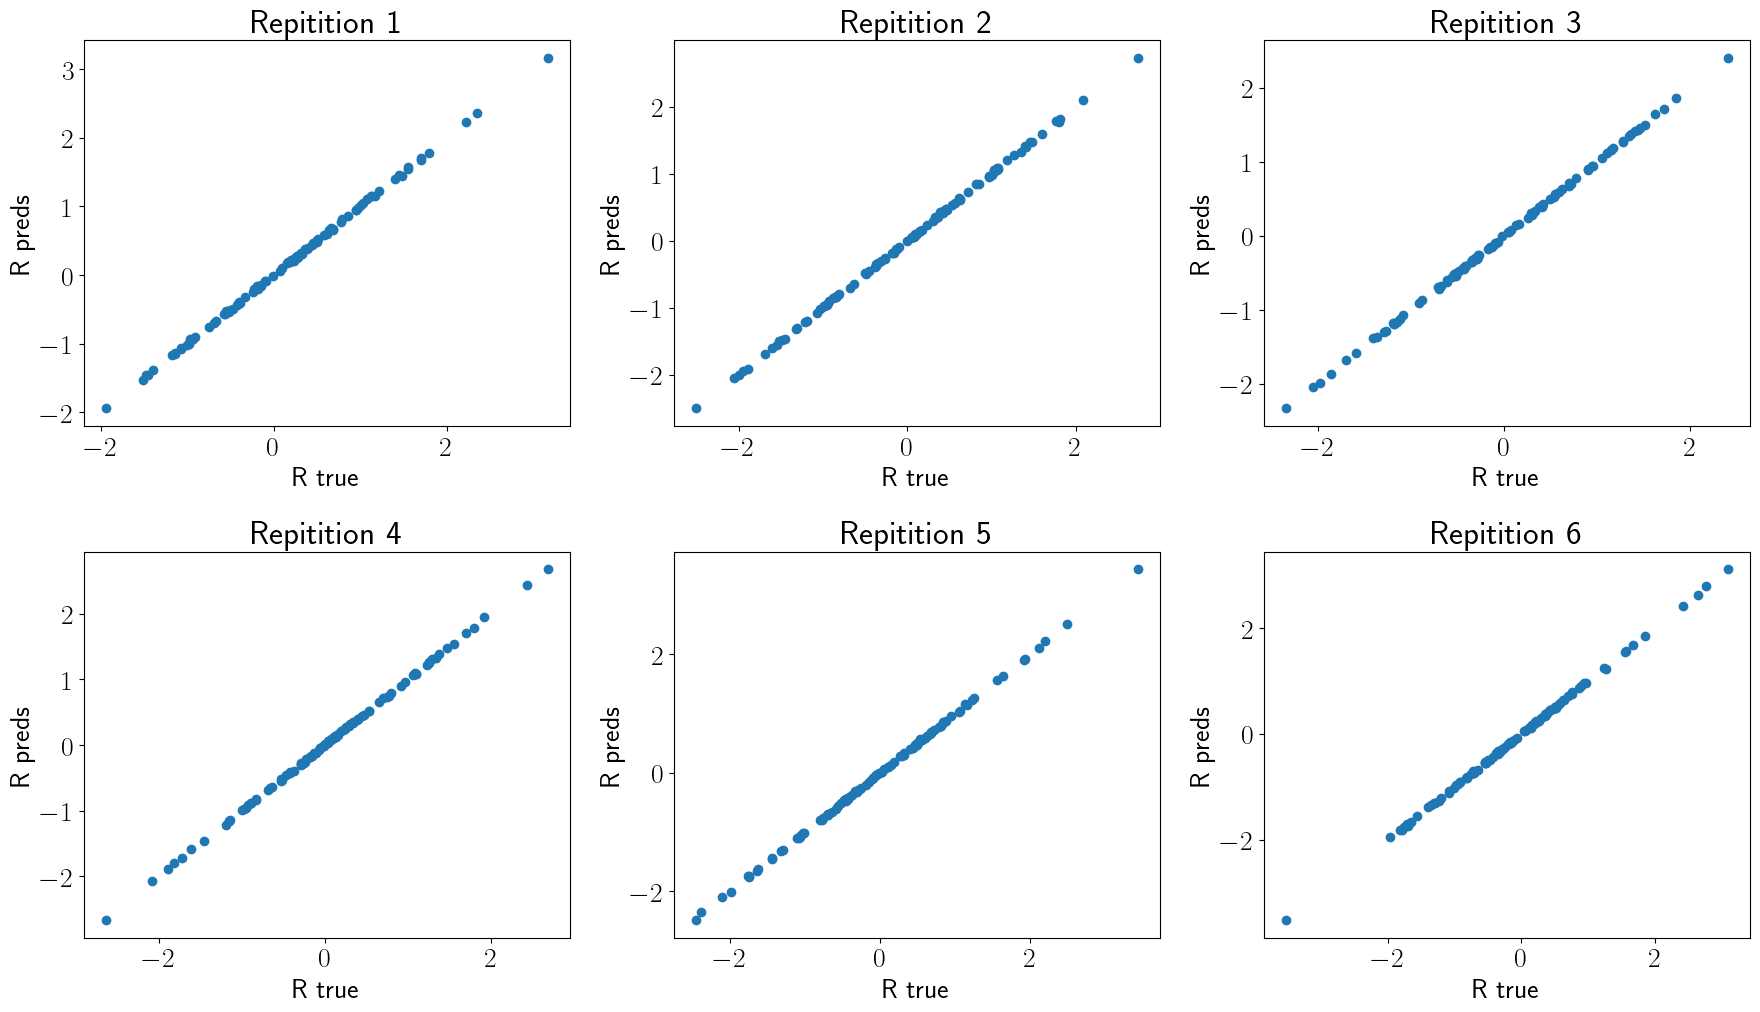

In [3]:

n = 100
m = 150
p = 2
d = 1


n_repititions = 6

# plt.figure(figsize=(7, 5))
plt.figure(figsize=(18, 15))

for ii in range(n_repititions):

    zx = onp.random.normal(size=(n, d))
    zy = onp.random.normal(size=(m, d))
    t = onp.random.normal(size=(n, d))
    W = onp.random.normal(size=(d, p))
    W = onp.array([[1,1]])
    S = onp.random.normal(size=(d, p))
    S = onp.array([[-1,1]])
    beta = onp.random.normal(size=(d, 1))
    beta = onp.array([[1]])
    sigma2 = 1e-2
    tau2 = 1e-2

    X = zx @ S + t @ W + onp.random.normal(scale=sigma2, size=(n, p))
    Y = zy @ S + onp.random.normal(scale=sigma2, size=(m, p))
    R = t @ beta + onp.random.normal(scale=tau2, size=(n, 1))

    model = LinearSSCR()
    model.fit(X, Y, R, d, verbose=False)

    preds = model.predict(X)


    plt.subplot(3, 3, ii + 1)
    plt.title("Repitition {}".format(ii + 1))
    plt.xlabel("R true")
    plt.scatter(R, preds)
    plt.ylabel("R preds")


plt.tight_layout()
plt.savefig("./out/simulation_example.png")
plt.show()



In [13]:
sample_size_list = [20, 100, 200, 500, 1_000]
p = 2
d = 1
n_repititions = 4
results = onp.zeros((n_repititions, len(sample_size_list)))
results_time = onp.zeros((n_repititions, len(sample_size_list)))

for ii in range(n_repititions):
    for jj, sample_size in enumerate(sample_size_list):

        n, m = sample_size, sample_size

        zx = onp.random.normal(size=(n, d))
        zy = onp.random.normal(size=(m, d))
        t = onp.random.normal(size=(n, d))
        W = onp.random.normal(size=(d, p))
        S = onp.random.normal(size=(d, p))
        beta = onp.random.normal(size=(d, 1))
        sigma2 = 1e-2
        tau2 = 1e-2

        X = zx @ S + t @ W + onp.random.normal(scale=sigma2, size=(n, p))
        Y = zy @ S + onp.random.normal(scale=sigma2, size=(m, p))
        R = t @ beta + onp.random.normal(scale=tau2, size=(n, 1))

        model = LinearSSCR()
        start = time.time()
        model.fit(X, Y, R, d, verbose=False)
        end = time.time()
        results_time[ii, jj] = end - start

        preds = model.predict(X)
        _, _, r2, _, _ = linregress(R.squeeze(), preds.squeeze())
        results[ii, jj] = r2

results_df_sample_size = pd.melt(pd.DataFrame(results, columns=sample_size_list))
results_df_time = pd.melt(pd.DataFrame(results_time, columns=sample_size_list))

In [12]:

p_list = [20, 100, 200] #, 500, 1_000]
n = 200
m = 200
d = 1
n_repititions = 4
results = onp.zeros((n_repititions, len(p_list)))
results_time = onp.zeros((n_repititions, len(p_list)))

for ii in range(n_repititions):
    for jj, p in enumerate(p_list):

        zx = onp.random.normal(size=(n, d))
        zy = onp.random.normal(size=(m, d))
        t = onp.random.normal(size=(n, d))
        W = onp.random.normal(size=(d, p))
        S = onp.random.normal(size=(d, p))
        beta = onp.random.normal(size=(d, 1))
        sigma2 = 1e-2
        tau2 = 1e-2

        X = zx @ S + t @ W + onp.random.normal(scale=sigma2, size=(n, p))
        Y = zy @ S + onp.random.normal(scale=sigma2, size=(m, p))
        R = t @ beta + onp.random.normal(scale=tau2, size=(n, 1))

        model = LinearSSCR()
        
        start = time.time()
        model.fit(X, Y, R, d, verbose=False)
        end = time.time()
        results_time[ii, jj] = end - start

        preds = model.predict(X)
        _, _, r2, _, _ = linregress(R.squeeze(), preds.squeeze())
        results[ii, jj] = r2

results_df_p = pd.melt(pd.DataFrame(results, columns=p_list))
results_df_p_time = pd.melt(pd.DataFrame(results_time, columns=p_list))

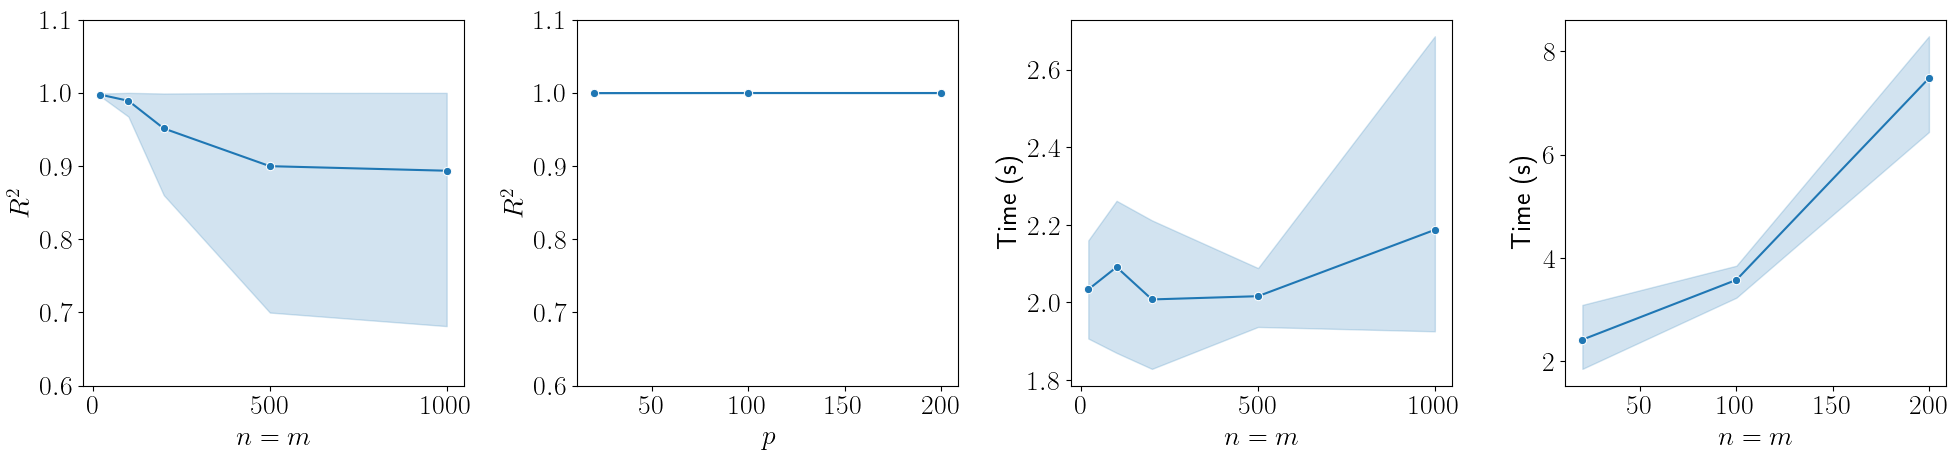

In [14]:
plt.figure(figsize=(20, 5))

plt.subplot(141)
sns.lineplot(data=results_df_sample_size, x="variable", y="value", marker="o")
plt.xlabel(r"$n = m$")
plt.ylabel(r"$R^2$")
plt.ylim(0.6, 1.1)

plt.subplot(142)
sns.lineplot(data=results_df_p, x="variable", y="value", marker="o")
plt.xlabel(r"$p$")
plt.ylabel(r"$R^2$")
plt.ylim(0.6, 1.1)

plt.subplot(143)
sns.lineplot(data=results_df_time, x="variable", y="value", marker="o")
plt.xlabel(r"$n = m$")
plt.ylabel(r"Time (s)")

plt.subplot(144)
sns.lineplot(data=results_df_p_time, x="variable", y="value", marker="o")
plt.xlabel(r"$n = m$")
plt.ylabel(r"Time (s)")

plt.tight_layout()
plt.savefig("./out/simulation_results.png")
plt.show()